### Homework 3

#### Set up

In [287]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score, accuracy_score

df_raw = pd.read_csv('../00-data/course_lead_scoring_2026.csv')
df = df_raw.copy()
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.head()


,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [288]:
df.dtypes

lead_source                     str
industry                        str
employment_status               str
location                        str
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [289]:
columns_categorical = ['industry', 'employment_status', 'location', 'lead_source']
columns_numeric = ['annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [290]:
# For categorical features, replace missing values with 'NA'
for c in columns_categorical:
    df[c] = df[c].fillna('NA')
# For numeric features, replace with 0.0
for c in columns_numeric:
    df[c] = df[c].fillna(0.0)
df.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

#### Question 1
What is the most frequent observation (mode) for the column industry?

In [291]:
solution = df['industry'].value_counts().sort_values(ascending=False).head(1)
print(f'Solution: {solution.index[0]} with {solution.values[0]} observations')


Solution: technology with 1173 observations


#### Question 2
Create the correlation matrix for the numerical features of your dataset. In a correlation matrix, you compute the correlation coefficient between every pair of features. What are the two features that have the biggest correlation?

- interaction_count and lead_score
- number_of_courses_viewed and lead_score
- number_of_courses_viewed and interaction_count
- annual_income and interaction_count

Only consider the pairs above when answering this question.

In [292]:
df_numerical = df.copy()
df_numerical = df_numerical.drop(columns=columns_categorical)
df_numerical.describe()

,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,50508.661000,2.089400,4.472600,0.491304,0.576600
std,24927.396949,1.188987,2.435906,0.202969,0.494147
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35082.750000,1.000000,3.000000,0.350000,0.000000
50%,52613.000000,2.000000,4.000000,0.490000,1.000000
75%,69752.750000,3.000000,6.000000,0.630000,1.000000
max,109886.000000,6.000000,13.000000,0.990000,1.000000


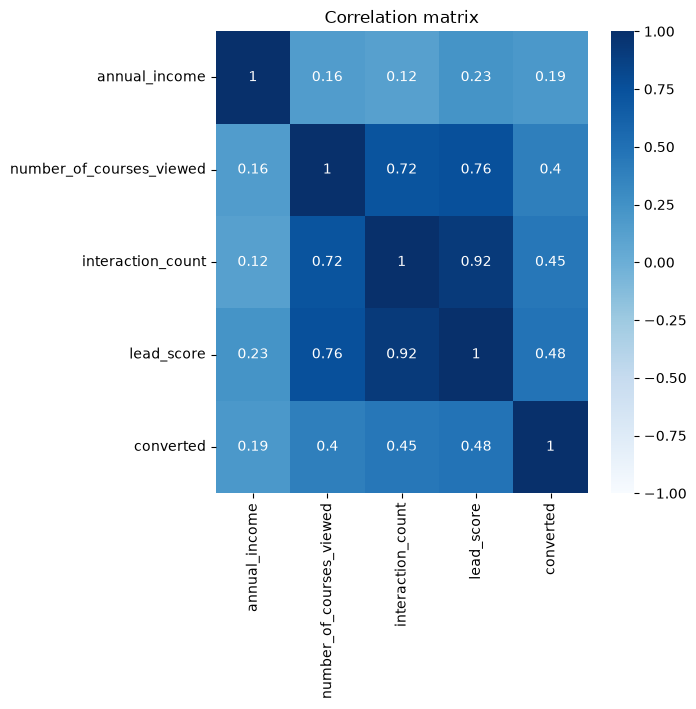

In [293]:
corr = df_numerical.corr()
plt.figure(figsize=(6, 6))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.show()

In [294]:
print(f'Biggest correlation: interaction_count and lead_score: {corr["interaction_count"]["lead_score"]:.2f}')

Biggest correlation: interaction_count and lead_score: 0.92


Split the data with these exact calls:

```python
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=42
)
```

Make sure that the target value converted is not in your dataframe.

In [295]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)
len(df_train), len(df_val), len(df_test)

(3000, 1000, 1000)

In [296]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
y_train = df_train.converted
y_val = df_val.converted
y_test = df_test.converted
df_train = df_train.drop(columns=['converted'])
df_val = df_val.drop(columns=['converted'])
df_test = df_test.drop(columns=['converted'])

#### Question 3
Calculate the mutual information score between converted and other categorical variables in the dataset. Use the training set only. Round the scores to 2 decimals using round(score, 2).
Which of these variables has the biggest mutual information score?

In [297]:
def calculate_mutual_information_in_train(columns):
    return mutual_info_score(columns, y_train)

df_train_categorical = df_train.copy()
df_train_categorical = df_train_categorical.drop(columns=columns_numeric)
mi = df_train_categorical.apply(calculate_mutual_information_in_train).sort_values(ascending=False).round(2)
mi


lead_source          0.03
employment_status    0.02
industry             0.00
location             0.00
dtype: float64

In [298]:
print(f'biggest mutual information: {mi.head(1).index[0]} with score {mi.head(1).values[0]}')

biggest mutual information: lead_source with score 0.03


#### Question 4
Now let's train a logistic regression.
- Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
- Fit the model on the training dataset.
- To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
    - model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    
Calculate the accuracy on the validation dataset and round it to 2 decimal digits.
What accuracy did you get?

In [299]:
dv = DictVectorizer(sparse=False)
df_train_dict = df_train[columns_categorical + columns_numeric].to_dict(orient='records')
X_train = dv.fit_transform(df_train_dict)
df_val_dict = df_val[columns_categorical + columns_numeric].to_dict(orient='records')
X_val = dv.transform(df_val_dict)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
accuracy = round(accuracy_score(y_val, y_pred), 2)
print(f'Accuracy: {accuracy}')


Accuracy: 0.65


#### Question 5
Let's find the least useful feature using the feature elimination technique.
Train a model using the same features and parameters as in Q4 (without rounding).
Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
For each feature, calculate the difference between the original accuracy and the accuracy without the feature.

Which of following feature has the smallest difference?

In [300]:
scores = pd.DataFrame(columns=['eliminated_column', 'original_accuracy', 'accuracy', 'diff'])
original_accuracy = accuracy
columns_all = df_train.columns.to_list()
columns_to_eliminate = ['lead_source', 'number_of_courses_viewed', 'interaction_count']

for col in columns_to_eliminate:
    colums_to_train = columns_all.copy()
    colums_to_train.remove(col)
    dv = DictVectorizer(sparse=False)
    df_train_dict = df_train[colums_to_train].to_dict(orient='records')
    X_train = dv.fit_transform(df_train_dict)
    df_valid_dict = df_val[colums_to_train].to_dict(orient='records')
    X_val = dv.transform(df_valid_dict)
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    scores.loc[len(scores)] = [col, original_accuracy, acc, abs(original_accuracy - acc)]
    scores = scores.sort_values(by='diff')

print(scores)


          eliminated_column  original_accuracy  accuracy   diff
1  number_of_courses_viewed               0.65     0.643  0.007
0               lead_source               0.65     0.642  0.008
2         interaction_count               0.65     0.601  0.049


In [301]:
min_diff_col = scores.loc[scores['diff'].idxmin(), 'eliminated_column']
print(f"Least useful feature: {min_diff_col}")

Least useful feature: number_of_courses_viewed


#### Question 6
Now let's train a regularized logistic regression.
Let's try the following values of the parameter C: [0.000001, 0.00001, 0.0001, 0.001].
Train models using all the features as in Q4.
Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

Which of these C leads to the best accuracy on the validation set?

In [302]:
c_candidates = [0.000001, 0.00001, 0.0001, 0.001]
scores = {}
dv = DictVectorizer(sparse=False)
df_train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(df_train_dict)
df_val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(df_val_dict)

for c in c_candidates:
    model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    score = accuracy_score(y_val, y_pred)
    scores[c] = score

df_scores = pd.DataFrame(scores.items(), columns=['C', 'Score'])
df_scores = df_scores.sort_values(by=['Score', 'C'], ascending=[False, True])
print(df_scores)


          C  Score
3  0.001000  0.645
2  0.000100  0.613
0  0.000001  0.598
1  0.000010  0.598


In [303]:
max_c = df_scores.loc[df_scores['Score'].idxmax(), 'C']
max_score = df_scores.loc[df_scores['Score'].idxmax(), 'Score']
print(f'Best C accuracy: {max_c} with {max_score}')

Best C accuracy: 0.001 with 0.645
